In [1]:
#Конспект Сережина Владимира
import sys
import array
import numpy as np
import random
import timeit
import matplotlib.pyplot as plt

In [2]:
'''динамическая типизация - причина 
по которой мы отказались от стандартной библиотеки Python и выбрали numpy'''
x = 1
print(type(x))

l = [True, "2", 3.0, 4]
print([type(i) for i in l])

import sys
print(sys.getsizeof(l))

<class 'int'>
[<class 'bool'>, <class 'str'>, <class 'float'>, <class 'int'>]
88


In [3]:
l1 = []
print(type(l1))
print(sys.getsizeof(l1)) #56 байтов ушли на хранение ПУСТО. Python написан на C (который хронит указатели и др.), что приводит к затрате на память

<class 'list'>
56


In [4]:
a1 = array.array('i', [1])
print(type(a1))

print(sys.getsizeof(a1))

<class 'array.array'>
84


In [5]:
print(np.__version__)

1.26.4


In [6]:
a = np.array([1, 2, 3, 4])

In [7]:
l = np.array(a1)

In [8]:
print(sys.getsizeof(a1))
print(sys.getsizeof(l))
#для малого количества данных списки лучше. Но для большого количества - списки numpy выгоднее

84
116


In [9]:
#повышающее поведение типов
a1 = np.array([1, 2, 3, 4])
print(type(a1), a1)

<class 'numpy.ndarray'> [1 2 3 4]


In [10]:
#повышающее поведение типов
a = np.array([1, 2, 3, 4, "a"])
print(type(a), a)

<class 'numpy.ndarray'> ['1' '2' '3' '4' 'a']


In [11]:
#явно задать тип
a = np.array([1.99, 2, 3, 4, 5], dtype = int)
print(type(a), a)

<class 'numpy.ndarray'> [1 2 3 4 5]


In [12]:
#одномерные массивы
a = np.array(range(2, 5))
print(a)

[2 3 4]


In [13]:
#многомерные массивы
a = np.array([range(i, i + 5)] for i in [1, 2, 3])
print(a) #Почему вывел генератор, а не матрицу?

<generator object <genexpr> at 0x00000209F1657A60>


In [14]:
# "с нуля"
print(np.zeros(10, dtype=int))

[0 0 0 0 0 0 0 0 0 0]


In [15]:
# из 1
print(np.ones((3, 5), dtype=float))

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [16]:
# предопределённое значение
print(np.full((3, 3), 3.1416))

[[3.1416 3.1416 3.1416]
 [3.1416 3.1416 3.1416]
 [3.1416 3.1416 3.1416]]


In [17]:
# линейная последовательность чисел
print(np.arange(0, 20, 2))
print(np.arange(0, 20, 3))

[ 0  2  4  6  8 10 12 14 16 18]
[ 0  3  6  9 12 15 18]


In [18]:
# в интервале с одинаковыми промежутками
print(np.linspace(0, 1, 11))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [19]:
# равномерное распределение от 0 до 1
print(np.random.random((2, 4)))

[[0.4698682  0.85865858 0.97850763 0.56173265]
 [0.71385182 0.73752714 0.30069041 0.86893342]]


In [20]:
print(np.random.normal((2, 4)))

[1.82099654 3.9511802 ]


In [21]:
# равномерное распределение от x до y
print(np.random.randint(0, 5, (2, 2)))

[[1 4]
 [3 1]]


In [22]:
# единичная матрица
print(np.eye(10, dtype=int))

[[1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1]]


In [23]:
#Типы данных
print(np.zeros(10, dtype=int))
print(np.zeros(10, dtype='int16'))
print(np.zeros(10, dtype=np.int16))

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [24]:
# ТЕМЫ КУРСА

# Numerical (числовой) Python = NumPy
# - атрибуты массивов
# - индексация
# - срезы
# - изменение формы
# - объединение и разбиение

In [25]:
# Атрибуты: ndim - число размерностей, shape - размер каждой размерности, size - общий размер массива

np.random.seed(1)

x1 = np.random.randint(10, size= 3)
print(x1)
print(x1.ndim, x1.shape, x1.size)

[5 8 9]
1 (3,) 3


In [26]:
x2 = np.random.randint(10, size= (3, 2))
print(x2)
print(x2.ndim, x2.shape, x2.size)

[[5 0]
 [0 1]
 [7 6]]
2 (3, 2) 6


In [27]:
x3 = np.random.randint(10, size= (3, 2, 4))
print(x3)
print(x3.ndim, x3.shape, x3.size)

[[[9 2 4 5]
  [2 4 2 4]]

 [[7 7 9 1]
  [7 0 6 9]]

 [[9 7 6 9]
  [1 0 1 8]]]
3 (3, 2, 4) 24


In [28]:
# Индексация (Indexing)
a = np.array([1, 2, 3, 4, 5])
print(a[0])
print(a[-2])

1
4


In [29]:
# Многомерные (Multidimensional arrays)
a = np.array([[0, 1], [2, 3]])
print(a)
print(a[0,0])
print(a[-1,-2])

a[1,0] = 100
print(a)

[[0 1]
 [2 3]]
0
2
[[  0   1]
 [100   3]]


In [30]:
# вставки

a = np.array([1, 2, 3, 4, 5])
print(a.dtype)

int32


In [31]:
a[0] = 3.14
print(a)
print(a.dtype)

[3 2 3 4 5]
int32


In [32]:
# a.dtype = float
# print(a)
# print(a.dtype)
# Мораль: не менять типы на ходу

In [33]:
# Срезы - подмассив массива [начало:конец:*шаг]
a = np.array([1, 2, 3, 4, 5])

print(a[:3])
print(a[3:])
print(a[1:4])

[1 2 3]
[4 5]
[2 3 4]


In [34]:
a = np.array([1, 2, 3, 4, 5])
print(a[1])

2


In [35]:
#Slices of multidensional massives
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(a)
print()
print(a[:2, :3])
print()
print(a[::-1, ::-1])
print()
# 1 3
# 5 7 
# 9 11
print(a[:, ::2])
print()
print(a[:, 0]) # рисуется как одномерный массив, хоть это и столбец!
print()
print(a[0, :]) # only first line

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

[[1 2 3]
 [5 6 7]]

[[12 11 10  9]
 [ 8  7  6  5]
 [ 4  3  2  1]]

[[ 1  3]
 [ 5  7]
 [ 9 11]]

[1 5 9]

[1 2 3 4]


In [36]:
# Срезы в Python - копии подмассивов, в NumPy - представления (view)
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(a)

a_2x2 = a[:2, :2]
print(a_2x2)

a_2x2[0, 0] = 999
print(a) #оригинальный массив поменялся!

a_2x2 = a[:2, :2].copy()
a_2x2[0, 0] = 1001 # Массив a не поменялся!
print(a)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[1 2]
 [5 6]]
[[999   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]
[[999   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]


In [37]:
# Форма массива. Изменение
a = np.arange(1, 13)
print(a, a.shape, a.ndim)

[ 1  2  3  4  5  6  7  8  9 10 11 12] (12,) 1


In [38]:
print(a[3])
print(a[11])

4
12


In [39]:
a1 = a.reshape(1, 12)
print(a1, a1.shape, a1.ndim)

[[ 1  2  3  4  5  6  7  8  9 10 11 12]] (1, 12) 2


In [40]:
print(a1[0, 3])
print(a1[0, 11])

4
12


In [41]:
a2 = a.reshape(2, 6)
print(a2, a2.shape, a2.ndim)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]] (2, 6) 2


In [42]:
# 12 = 2*6=2*2*3= 1*12*1*1
a3 = a.reshape(2, 2, 3)
print(a3, a3.shape, a3.ndim, a3.size)
print()
print(a3[0, 1, 2])

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]] (2, 2, 3) 3 12

6


In [43]:
# 12 = 2*6=2*2*3= 1*12*1*1
a4 = a.reshape(1, 12, 1, 1)
print(a4, a4.shape, a4.ndim)
print(a4[0, 3, 0, 0])

[[[[ 1]]

  [[ 2]]

  [[ 3]]

  [[ 4]]

  [[ 5]]

  [[ 6]]

  [[ 7]]

  [[ 8]]

  [[ 9]]

  [[10]]

  [[11]]

  [[12]]]] (1, 12, 1, 1) 4
4


In [44]:
a5 = a.reshape((2, 6)) # Хороший тон - писать размерности в виде кортежа!
print(a5, a5.shape, a5.ndim)
print(a5[1, 5])

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]] (2, 6) 2
12


In [45]:
a6 = a.reshape((2, 6), order="F") # Заполнение матрицы поменяли с горизонтального на вертикальный!
print(a6, a6.shape, a6.ndim)
print(a6[1, 4])

[[ 1  3  5  7  9 11]
 [ 2  4  6  8 10 12]] (2, 6) 2
10


In [46]:
a7 = a.reshape((2, 6), order="C") # Транспонируем матрицу
print(a7, a7.shape, a7.ndim)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]] (2, 6) 2


In [47]:
a = np.arange(1, 13) # С точки зрения NumPy, a - не матрциа.
print(a, a.shape, a.ndim)

a1 = a.reshape(1, 12)
print(a1, a1.shape, a1.ndim) #This's already a matrix

[ 1  2  3  4  5  6  7  8  9 10 11 12] (12,) 1
[[ 1  2  3  4  5  6  7  8  9 10 11 12]] (1, 12) 2


In [48]:
a2 = a[np.newaxis, :] # Adding a new axis
print(a2, a2.shape, a2.ndim)

[[ 1  2  3  4  5  6  7  8  9 10 11 12]] (1, 12) 2


In [49]:
# Слияние и разбинение массива

# Одномерные
x = np.array([1, 2, 3])
y = np.array([4, 5])
z = np.array([6])

xyz = np.concatenate([x, z, y])
print(xyz)

[1 2 3 6 4 5]


In [50]:
# Двумерные
x = np.array([[1, 2, 3], [4, 5, 6]])
y = np.array([[7, 8, 9], [10, 11, 12]])

xy1 = np.concatenate([x, y])
print(xy1)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [51]:
xy2 = np.concatenate([x, y], axis = 1)
print(xy2)

[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]


In [52]:
x = np.array([[1, 2, 3], [4, 5, 6]])
y = np.array([[7, 8, 9], [10, 11, 12]])

print(np.vstack([x, y]), end = '\n\n') # axis = 0

print(np.dstack([x, y]), end = '\n\n') 

print(np.hstack([x, y])) # axis = 1

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

[[[ 1  7]
  [ 2  8]
  [ 3  9]]

 [[ 4 10]
  [ 5 11]
  [ 6 12]]]

[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]


In [53]:
# Разбиение массивов
xy = np.vstack([x, y])
print(xy)

print(np.split(xy, [0, 3], axis = 0), end = '\n\n') # По первой оси
print(np.split(xy, [1], axis = 1), end = '\n\n') # По второй оси
print(np.hsplit(xy, [1])) # hsplit - сокращённо split(hstack); dsplit, vsplit

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[array([], shape=(0, 3), dtype=int32), array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]]), array([[10, 11, 12]])]

[array([[ 1],
       [ 4],
       [ 7],
       [10]]), array([[ 2,  3],
       [ 5,  6],
       [ 8,  9],
       [11, 12]])]

[array([[ 1],
       [ 4],
       [ 7],
       [10]]), array([[ 2,  3],
       [ 5,  6],
       [ 8,  9],
       [11, 12]])]


In [54]:
z = np.dstack([x, y])
print(z, end = '\n\n')
print(np.dsplit(z, [1]))

[[[ 1  7]
  [ 2  8]
  [ 3  9]]

 [[ 4 10]
  [ 5 11]
  [ 6 12]]]

[array([[[1],
        [2],
        [3]],

       [[4],
        [5],
        [6]]]), array([[[ 7],
        [ 8],
        [ 9]],

       [[10],
        [11],
        [12]]])]


In [55]:
# Универсальные функции - быстрее циклов for and while
x = np.arange(1, 10)
print(x)

[1 2 3 4 5 6 7 8 9]


In [56]:
def f(x):
    out = np.empty(len(x))
    for i in range(len(x)):
        out[i] = 1.0 / x[i]
    return out

In [57]:
print(f(x))
print(1.0 / x)

[1.         0.5        0.33333333 0.25       0.2        0.16666667
 0.14285714 0.125      0.11111111]
[1.         0.5        0.33333333 0.25       0.2        0.16666667
 0.14285714 0.125      0.11111111]


In [58]:
print(timeit.timeit(stmt="f(x)", globals=globals())) #Работает на порядок дольше!
print(timeit.timeit(stmt="1.0 / x", globals=globals()))

15.08263399999123
1.2566828998969868


In [59]:
# УФ. Арифметические операции

x = np.arange(5)
print(x)

print(x + 1)
print(x - 1)
print(x * 2)
print(x / 2)
print(x % 3)
print(-x)
print(x**2)

print(x * 2 - 2)

print(x + 1)
print(np.add(x, 1)) # Есть некоторые преимущества

print(abs(x)) # Python
print(np.abs(x)) # It's better
print(np.absolute(x))

[0 1 2 3 4]
[1 2 3 4 5]
[-1  0  1  2  3]
[0 2 4 6 8]
[0.  0.5 1.  1.5 2. ]
[0 1 2 0 1]
[ 0 -1 -2 -3 -4]
[ 0  1  4  9 16]
[-2  0  2  4  6]
[1 2 3 4 5]
[1 2 3 4 5]
[0 1 2 3 4]
[0 1 2 3 4]
[0 1 2 3 4]


In [60]:
# УФ. Тригонометрические функции
# sin, cos, tan, ctg, arccos, arcsin, arctan, arcctg

# УФ. Показательные и логарифмы
# exp, power, log, log2, log10

x = [0, 0.0001, 0.001, 0.01, 0.1]

In [61]:
print("exp = ", np.exp(x))
print("exp - 1= ", np.expm1(x))

exp =  [1.         1.00010001 1.0010005  1.01005017 1.10517092]
exp - 1=  [0.00000000e+00 1.00005000e-04 1.00050017e-03 1.00501671e-02
 1.05170918e-01]


In [62]:
print("log(x) = ", np.log(x))
print("log(1+x) = ", np.log1p(x))

log(x) =  [       -inf -9.21034037 -6.90775528 -4.60517019 -2.30258509]
log(1+x) =  [0.00000000e+00 9.99950003e-05 9.99500333e-04 9.95033085e-03
 9.53101798e-02]


C:\Users\staso\AppData\Local\Temp\ipykernel_20784\4268278788.py:1: RuntimeWarning: divide by zero encountered in log
  print("log(x) = ", np.log(x))


In [63]:
# УФ.
x = np.arange(10)
print(x)
y = 10 * x
print(y)

z = np.empty(len(x))
np.multiply(x, 10, out=z)
print(z)

[0 1 2 3 4 5 6 7 8 9]
[ 0 10 20 30 40 50 60 70 80 90]
[ 0. 10. 20. 30. 40. 50. 60. 70. 80. 90.]


In [64]:
x = np.arange(5)
z = np.zeros(10)
print(x) 
print(z)
z[::2] = x*10
print(z)

[0 1 2 3 4]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 0.  0. 10.  0. 20.  0. 30.  0. 40.  0.]


In [65]:
z = np.zeros(10)
np.multiply(x, 10, out=z[::2])
print(z)

[ 0.  0. 10.  0. 20.  0. 30.  0. 40.  0.]


In [66]:
# Сводные показатели
x = np.arange(1, 5)
print(x)
print(np.add.reduce(x))
print(np.add.accumulate(x))
print(np.multiply.accumulate(x))
print(np.subtract.accumulate(x))
print(np.sum(x))
print(np.cumsum(x))
print(np.prod(x))
print(np.cumprod(x))

[1 2 3 4]
10
[ 1  3  6 10]
[ 1  2  6 24]
[ 1 -1 -4 -8]
10
[ 1  3  6 10]
24
[ 1  2  6 24]


In [67]:
x = np.arange(1, 10)
print(np.add(x, x))
print(np.multiply.outer(x, x))

[ 2  4  6  8 10 12 14 16 18]
[[ 1  2  3  4  5  6  7  8  9]
 [ 2  4  6  8 10 12 14 16 18]
 [ 3  6  9 12 15 18 21 24 27]
 [ 4  8 12 16 20 24 28 32 36]
 [ 5 10 15 20 25 30 35 40 45]
 [ 6 12 18 24 30 36 42 48 54]
 [ 7 14 21 28 35 42 49 56 63]
 [ 8 16 24 32 40 48 56 64 72]
 [ 9 18 27 36 45 54 63 72 81]]


In [68]:
# Агрегирование данных
np.random.seed(3)
s = np.random.random(10)
print(sum(s)) # python
print(np.sum(s))

4.67502334813787
4.67502334813787


In [69]:
a = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])
print(sum(a)) # python

print(np.sum(a))
print(np.sum(a, axis=0)) # 0 - vertical direction (columns)
print(np.sum(a, axis=1)) # 1 - horizontal direction (rows)

print(type(a))
print(a.sum())
print(a.sum(0))
print(a.sum(1))

print(sum(a, 1)) # установили начальное значение суммы

[ 7  9 11 13 15]
55
[ 7  9 11 13 15]
[15 40]
<class 'numpy.ndarray'>
55
[ 7  9 11 13 15]
[15 40]
[ 8 10 12 14 16]


In [70]:
# min, max - analogically to the 'sum'
print(np.max(a))

10


In [71]:
# mean, std, var, median, argmin, argmax, percentile, any, all
# nan*

# Not a number element - NaN

# Транслирование (broadcasting)

a = np.array([1, 2, 3])
b = np.array([5])
print(a + b)
# 6, 7, 8

print(a + 5)
# 6, 7, 8

[6 7 8]
[6 7 8]


In [72]:
# Правила транслирования (broadcasting)

''' 
1. Сравниваются размерности двух массивов. Если размерности
отличаются, то форма массива с меньшей размерностью дополняется
единицами с левой стороны.

2. Если формы двух массивов не совпадают в каком-то измерении, то 
массив с формой, равной 1 в данном измерении "растягивается" до
соответствия форме другого массива.

3. Если в каком-либе измерении размеры массивов различаются, то
генерируется ошибка.
'''


a = np.ones([2, 3])
b = np.arange(3)
c = np.ones([1, 3])

print(a)
print(b)
print(c)

print(a.shape)
print(b.shape) # Одномерный массив длины 3 - это не то же самое, что строка 1:3!
print(c.shape)


c = a + b

# 1. a -> (2,3), b -> (3,)  ====>>> a = (2, 3), b = (1, 3)

# 2. a = (2, 3), b = (1,3) => b = (2,3)
# 1 1 1
# 1 1 1

# 0 1 2
# 0 1 2

# 3. Ошибки нет

print(c)

[[1. 1. 1.]
 [1. 1. 1.]]
[0 1 2]
[[1. 1. 1.]]
(2, 3)
(3,)
(1, 3)
[[1. 2. 3.]
 [1. 2. 3.]]


In [73]:
a = np.arange(3).reshape(3, 1)
b = np.arange(3)
print(a)
print(b)
print(a.shape)
print(b.shape)
print(a + b)
print(a * b) # Поэлементное умножение, а не матричное!

# 1. a -> (3,1), b -> (3,)  ===>>> a -> (3,1), b -> (1,3)
# 2. b -> (3,3), a -> (3,3) - дублируем строки и столбцы / duplicate the rows and the columns
# No error

[[0]
 [1]
 [2]]
[0 1 2]
(3, 1)
(3,)
[[0 1 2]
 [1 2 3]
 [2 3 4]]
[[0 0 0]
 [0 1 2]
 [0 2 4]]


In [74]:
a = np.arange(3,2)
b = np.arange(3)
print(a)
print(b)
try:
    print(a + b)
except ValueError:
    print('Ошибка (см. пункт 3). a -> (3,2), b -> (3,3)')

[]
[0 1 2]
Ошибка (см. пункт 3). a -> (3,2), b -> (3,3)


In [75]:
# Варианты применения транслирования.
# 1. Центрирование массивов (Centering an array)

a = np.array([[1,2,3,4,5,6,7,8,9], [9,8,7,6,5,4,3,2,1]])
print(a)

aMean = a.mean(0) # vertical direction - by rows
print(aMean)

print(a.shape)
print(aMean.shape)

aCentr = a - aMean # Centering the array
print(aCentr)

print(aCentr.mean(0))

[[1 2 3 4 5 6 7 8 9]
 [9 8 7 6 5 4 3 2 1]]
[5. 5. 5. 5. 5. 5. 5. 5. 5.]
(2, 9)
(9,)
[[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
 [ 4.  3.  2.  1.  0. -1. -2. -3. -4.]]
[0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [76]:
a = np.array([[1,2,3,4,5,6,7,8,9], [9,8,7,6,5,4,3,2,1]])
print(a)

aMean = a.mean(1) # horizontal direction - by columns
print(aMean)
print(aMean.shape)

aMean = aMean[:, np.newaxis] # 'reshape' is also suitable
print(aMean)
print(aMean.shape)

aCentr = a - aMean
print(aCentr)

[[1 2 3 4 5 6 7 8 9]
 [9 8 7 6 5 4 3 2 1]]
[5. 5.]
(2,)
[[5.]
 [5.]]
(2, 1)
[[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
 [ 4.  3.  2.  1.  0. -1. -2. -3. -4.]]


(100,)
(100, 1)
(100, 100)


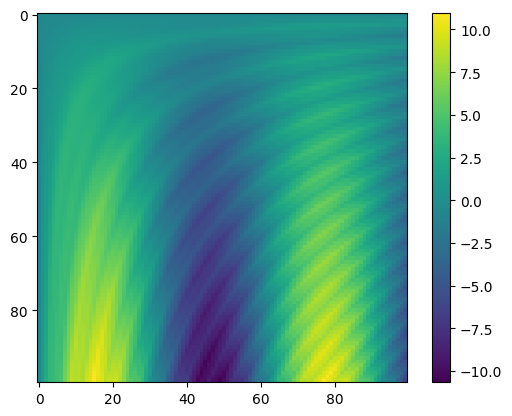

In [77]:
# Варианты применения транслирования - Examples of using broadcasting.
# 2. Plotting a graph
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
y = y[:, np.newaxis]

print(x.shape)
print(y.shape)

z = np.sin(x) * y + np.cos(10 + y * x)**3
print(z.shape)

plt.imshow(z)
plt.colorbar()

In [78]:
# Маскирование
x = np.arange(1, 5)
print(x)
print(x < 3)
print(x > 3)
print(np.less(x,3))
# >, <, >=, <=, != and their verbal analogs

rng1 = np.random.default_rng(seed = 1)
rng2 = np.random.default_rng(seed = 10)
x = rng1.integers(10, size=(3, 4))
print('x =', x)
print(x < 6)

# Сколько элементов имеют значение меньше 6
print(np.count_nonzero(x < 6))
print(np.sum(x < 6)) # the same, but...
print(np.sum(x < 6, axis = 0)) # we can choose a direction
print(np.sum(x < 6, axis = 1))

print(np.any(x > 0))
print(np.any(x < 0))

print(np.all(x > 10))
print(np.all(x != 11))

print(np.sum((x > 3) & (x < 9), axis = 0))
print(np.sum((np.greater(x,3)) & (np.less(x,9)), axis = 0))

[1 2 3 4]
[ True  True False False]
[False False False  True]
[ True  True False False]
x = [[4 5 7 9]
 [0 1 8 9]
 [2 3 8 4]]
[[ True  True False False]
 [ True  True False False]
 [ True  True False  True]]
7
7
[3 3 0 1]
[2 2 3]
True
False
False
True
[1 1 3 1]
[1 1 3 1]


In [79]:
# Наложение маски (bitmasking)
print('x =', x)
a = x[x < 5] # 1-dimensional array, but we had the multidimensional one!
print(a)
print(a.shape)

x = [[4 5 7 9]
 [0 1 8 9]
 [2 3 8 4]]
[4 0 1 2 3 4]
(6,)


In [80]:
# and or & ~ |
print(bool(42), bool(0))
print(bool(42) and bool(0))
print(bool(42) or bool(0))

print(bin(42))
print(bin(59))

print(42 & 59, 42 and 59)
print(42 | 59, 42 or 59)

True False
False
True
0b101010
0b111011
42 59
59 42


In [81]:
a = np.array([1,0,1,0,1], dtype=bool)
b = np.array([1,1,1,1,9], dtype=bool)
print(a & b)

[ True False  True False  True]


In [82]:
# Способы доступы к элементам - Approaches of accessing elements
a = np.arange(1,10)
print(a)
print(a[3]) # Indexing
print(a[3:4]) # Slicing
print(a[a==3]) # Boolean masking (binmask)

# векторизация / прихотливая (fancy)
a = np.arange(1, 10)
print(a)
ind = [3,5,0]
print(a[ind])

ind = [[3,5],[0,3]]
# print(a[ind]) - it doesn't work in my Python

[1 2 3 4 5 6 7 8 9]
4
[4]
[3]
[1 2 3 4 5 6 7 8 9]
[4 6 1]


In [83]:
a = np.arange(12).reshape(3,4)
print(a)

row = np.array([0,1,2])
col = np.array([2,1,3])
print(a[row, col])

print(row.shape) # (3,)
print(col.shape) # (3,)

print(a[row[:, np.newaxis], col])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[ 2  5 11]
(3,)
(3,)
[[ 2  1  3]
 [ 6  5  7]
 [10  9 11]]


In [84]:
'''
Kinds of indexing:
1. Indices
2. Slices
3. Masking
'''
x = np.arange(12).reshape(3,4)
print(x, end = '\n\n')

# indices
print(x[2], end = '\n\n')
print(x[2, [2, 0, 1]], end = '\n\n')
print(x[[2, 0, 1], 2], end = '\n\n')

# slices
print(x[1:], end = '\n\n')
print(x[1:, [2, 0, 1]], end = '\n\n')

# masking
mask = np.array([1, 0, 1, 0], dtype = bool)
print(mask)
print(mask.shape)
row = np.array([0, 1, 2])
# Механизм broadcasting запускается автоматически для всего, что передано как индекс
print(x[row[:, np.newaxis], mask]) # advansed indexing + broadcasting

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

[ 8  9 10 11]

[10  8  9]

[10  2  6]

[[ 4  5  6  7]
 [ 8  9 10 11]]

[[ 6  4  5]
 [10  8  9]]

[ True False  True False]
(4,)
[[ 0  2]
 [ 4  6]
 [ 8 10]]


In [85]:
x = np.arange(12).reshape(3,4)
print(x)
mask = np.array([1, 1, 1, 1], dtype = bool)
row = np.array([0, 1, 2])
# x[0][0] x[1][1] x[2][2]
print(mask.shape) # it's also possible to do like in the previous instance
# (4,)
print(row.shape)
# (3,)
print(x[row[:, np.newaxis], mask])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
(4,)
(3,)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


[26 86  2 55 75 93 16 73 54 95 53 92 78 13  7 30 22 24 33  8 43 62  3 71
 45 48  6 99 82 76]


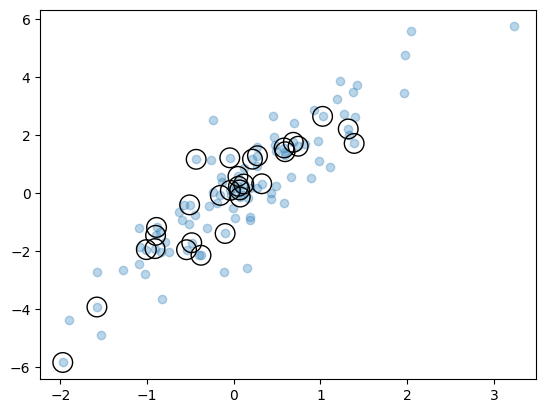

In [86]:
rng = np.random.default_rng(seed=1)
x = rng.multivariate_normal([0,0], [[1,2], [2,5]], 100)


np.random.seed(0)
inx = np.random.choice(100, 30, replace=False)
print(inx)

select =x[inx]

plt.scatter(x[:,0], x[:,1], alpha=0.3)
plt.scatter(select[:,0], select[:,1], s=200, facecolor="none", edgecolor="black")
plt.show()

In [87]:
x = np.arange(10)
print(x)
inx = np.array([2, 9, 4, 1, 4, 4, 4, 4, 4])

# x[inx] = 99
# x[inx] += 1
np.add.at(x, inx, 1) # unbuferred in-place addition
print(x)

[0 1 2 3 4 5 6 7 8 9]
[ 0  2  3  3 10  5  6  7  8 10]


In [88]:
rng = np.random.default_rng(seed=1)
x = rng.integers(100, size=100)
print(x[:10])

intervals = np.linspace(0, 100, 11)
print(intervals)

counts = np.zeros(11)
print(counts)

i = np.searchsorted(intervals, x) # e.g: The number 14 would be placed at index 1, between 10 and 20
print(i[:10])

np.add.at(counts, i, 1)
print(counts)
print(np.sum(counts))

[47 51 75 95  3 14 82 94 24 31]
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 5  6  8 10  1  2  9 10  3  4]
[ 0.  9.  9. 11.  9. 14. 10.  5. 13. 11.  9.]
100.0


In [89]:
# Sorting
a = [3,2,5,1,4,6,78,3,54,6,3,2,4,59]
print(sorted(a)) # Python's built-in function (out-of-place modification)
print(a)
a.sort() # in-place modification
print(a)

[1, 2, 2, 3, 3, 3, 4, 4, 5, 6, 6, 54, 59, 78]
[3, 2, 5, 1, 4, 6, 78, 3, 54, 6, 3, 2, 4, 59]
[1, 2, 2, 3, 3, 3, 4, 4, 5, 6, 6, 54, 59, 78]


In [90]:
a = [3,2,5,1,4,6,78,3,54,6,3,2,4,59]
x = np.array(a)
print(x)
print(np.sort(x)) # sorted (out-of-place)
print(x)

inx = np.argsort(x) # it returns indices
print(inx)
print(x[inx])

[ 3  2  5  1  4  6 78  3 54  6  3  2  4 59]
[ 1  2  2  3  3  3  4  4  5  6  6 54 59 78]
[ 3  2  5  1  4  6 78  3 54  6  3  2  4 59]
[ 3  1 11  0  7 10  4 12  2  5  9  8 13  6]
[ 1  2  2  3  3  3  4  4  5  6  6 54 59 78]


In [91]:
rng = np.random.default_rng(seed=1)
x = rng.integers(0,10, size=(4,6))
print(x, end='\n\n')

print(np.sort(x, axis=0), end='\n\n')
print(np.sort(x, axis=1), end='\n\n')

[[4 5 7 9 0 1]
 [8 9 2 3 8 4]
 [2 8 2 4 6 5]
 [0 0 8 7 8 5]]

[[0 0 2 3 0 1]
 [2 5 2 4 6 4]
 [4 8 7 7 8 5]
 [8 9 8 9 8 5]]

[[0 1 4 5 7 9]
 [2 3 4 8 8 9]
 [2 2 4 5 6 8]
 [0 0 5 7 8 8]]



In [92]:
# структурированные массивы (Structured massives)
# массивы записей

name = ['Ирина', 'Виталий', 'Олег', 'Саша']
age = [25, 17, 52, 44.5]
weight = [55.0, 57, 78, 72]

i = 1
print(name[i], age[i], weight[i]) # not laconic

my_dtype = {
    'names': ('name_', 'age_', 'weight_'),
    'formats': ('U10', 'i4', 'f8') # U10 - string with less than 10 elements
}

data = np.zeros(4, dtype=my_dtype)

data['name_'] = name
data['age_'] = age
data['weight_'] = weight

print(data.dtype)
print(data['name_'])
print(data[0])
print(data[-1]['name_'])

data_rec = data.view(np.recarray) # it allows us to work with e.g. 'age' like with an attribute
print(data_rec)

print(data_rec.name_)
print(data_rec[0])
print(data_rec[-1].name_)

print(data['age_'] < 30)
print(data[data['age_'] < 30]['name_'])

Виталий 17 57
[('name_', '<U10'), ('age_', '<i4'), ('weight_', '<f8')]
['Ирина' 'Виталий' 'Олег' 'Саша']
('Ирина', 25, 55.)
Саша
[('Ирина', 25, 55.) ('Виталий', 17, 57.) ('Олег', 52, 78.)
 ('Саша', 44, 72.)]
['Ирина' 'Виталий' 'Олег' 'Саша']
('Ирина', 25, 55.)
Саша
[ True  True False False]
['Ирина' 'Виталий']


In [93]:
tp = np.dtype([('id', 'i8'), ('mat', 'f8', (3, 3))])
x = np.zeros(2, dtype=tp)
print(x, end='\n\n')

x['mat'][0] = np.array([[1,2,3], [4,5,6], [7,8,9]])
print(x)

[(0, [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]])
 (0, [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]])]

[(0, [[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])
 (0, [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]])]




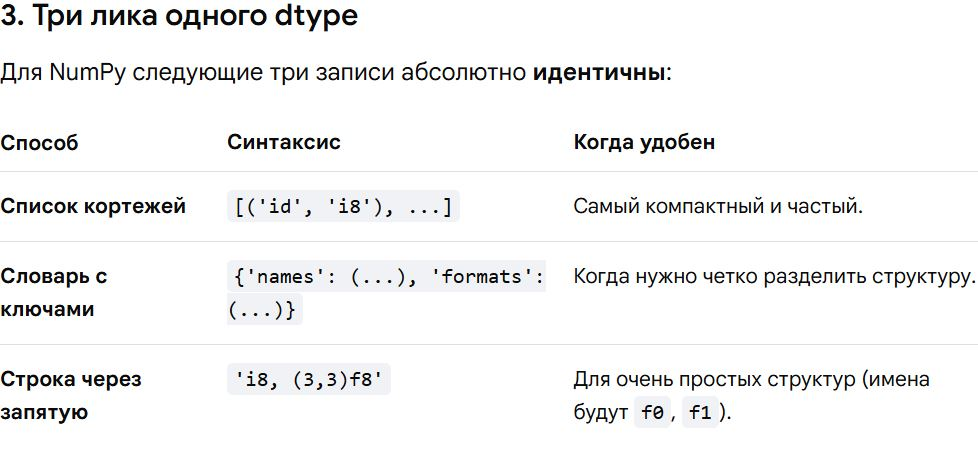

In [94]:
data = [('Ирина', 25, 55.0), ('Виталий', 17, 57), ('Олег', 52, 78), ('Саша', 44.5, 72)]

my_dtype = {
    'names': ('name_', 'age_', 'weight_'),
    'formats': ('U10', 'i4', 'f8')
}

data_rec = np.rec.array(data, dtype=my_dtype)
print(data_rec)
print(data_rec.name_)

[('Ирина', 25, 55.) ('Виталий', 17, 57.) ('Олег', 52, 78.)
 ('Саша', 44, 72.)]
['Ирина' 'Виталий' 'Олег' 'Саша']
